In [1]:
import pandas as pd
import numpy as np
import csv
import math
from pathlib import Path
import datetime as dt
import matplotlib.pyplot as plt

In [51]:
spx_df = pd.read_csv('/Users/jplatta/.tickrake/data/history/ibkr-paper/SPX_day.csv', header=0)
spx_df.index = pd.to_datetime(spx_df['datetime']).dt.date
spx_df = spx_df.loc[spx_df.index >= pd.to_datetime('2026-01-01').date()]

vix_df = pd.read_csv('/Users/jplatta/.tickrake/data/history/ibkr-paper/VIX_day.csv', header=0)
vix_df.index = pd.to_datetime(vix_df['datetime']).dt.date
vix_df = vix_df.loc[vix_df.index >= pd.to_datetime('2026-01-01').date()]

vix9d_df = pd.read_csv('/Users/jplatta/.tickrake/data/history/ibkr-paper/VIX9D_day.csv', header=0)
vix9d_df.index = pd.to_datetime(vix9d_df['datetime']).dt.date
vix9d_df = vix9d_df.loc[vix9d_df.index >= pd.to_datetime('2026-01-01').date()]

## 30 Day

In [52]:
study_df = pd.DataFrame()
study_df['spx_close'] = spx_df['close']
study_df['spx_log_ret'] = np.log(spx_df['close'] / spx_df['close'].shift(1))
study_df['rv'] = 100  * np.sqrt(
    252 / 30 * study_df['spx_log_ret'].rolling(30).apply(lambda x: (x**2).sum())
)
study_df['iv'] = vix_df['close']
study_df.index = spx_df.index
study_df = study_df.dropna()
study_df = study_df.drop(['spx_close','spx_log_ret'], axis=1)

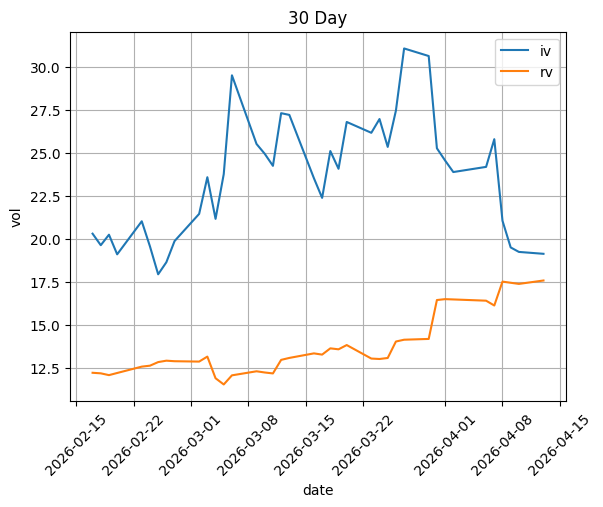

In [54]:
plt.figure()

plt.plot(study_df.index, study_df['iv'], label='iv')
plt.plot(study_df.index, study_df['rv'], label='rv')
plt.xlabel('date')
plt.ylabel('vol')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.title('30 Day')
plt.show()

## 9 Day

In [55]:
study_df = pd.DataFrame()
study_df['spx_close'] = spx_df['close']
study_df['spx_log_ret'] = np.log(spx_df['close'] / spx_df['close'].shift(1))
study_df['rv'] = 100  * np.sqrt(
    252 / 9 * study_df['spx_log_ret'].rolling(9).apply(lambda x: (x**2).sum())
)
study_df['iv'] = vix9d_df['close']
study_df.index = spx_df.index
study_df = study_df.dropna()
study_df = study_df.drop(['spx_close','spx_log_ret'], axis=1)

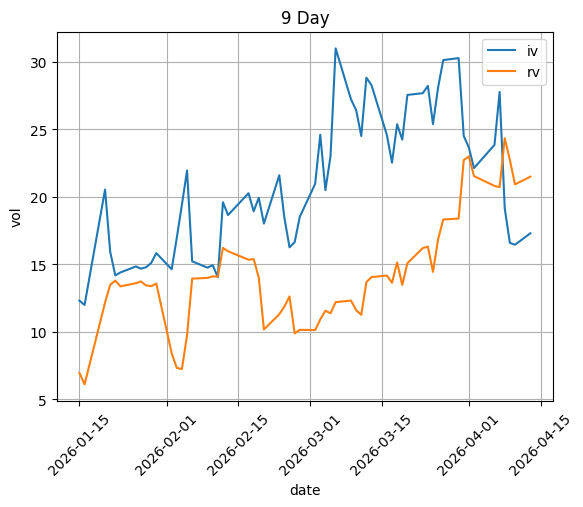

In [57]:
plt.figure()

plt.plot(study_df.index, study_df['iv'], label='iv')
plt.plot(study_df.index, study_df['rv'], label='rv')
plt.xlabel('date')
plt.ylabel('vol')
plt.grid()
plt.legend()
plt.xticks(rotation=45)
plt.title('9 Day')
plt.show()